In [1]:
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'
    get_ipython().system('pip install -q torch-fidelity open-clip-torch lpips scikit-image tqdm')
except ModuleNotFoundError:
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')

for p in (DRIVE_ROOT, AI_TOOLKIT):
    if p not in sys.path:
        sys.path.insert(0, p)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.7 MB/s eta 0:00:00
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma


In [2]:
import json
import shutil
from pathlib import Path

real_dir = f'{DRIVE_ROOT}/data/png_512_test'
Path(real_dir).mkdir(parents=True, exist_ok=True)

with open(f'{DRIVE_ROOT}/data/test_500.jsonl') as f:
    test_pairs = [json.loads(l) for l in f]

for item in test_pairs:
    shutil.copy(item['png_path'], real_dir)
print(f"Copied {len(test_pairs)} real images to {real_dir}")


Copied 500 real images to /content/drive/MyDrive/liya_diploma/data/png_512_test


In [8]:
import json
from pathlib import Path

from scripts.compute_metrics import compute_fid, compute_clip_score

captions = [p['caption'] for p in test_pairs]

EXPERIMENTS = {
    "SD1.5 Baseline":  f'{DRIVE_ROOT}/results/experiments/sd15_baseline',
    "SDXL LoRA r4":    f'{DRIVE_ROOT}/results/experiments/sdxl_r4_samples',
    "SDXL LoRA r8":    f'{DRIVE_ROOT}/results/experiments/sdxl_r8_samples',
    "SDXL LoRA r16":   f'{DRIVE_ROOT}/results/experiments/sdxl_r16_samples',
    "SDXL LoRA r32":   f'{DRIVE_ROOT}/results/experiments/sdxl_r32_samples',
    "SDXL r16 s500":   f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s500_samples',
    "SDXL r16 s1000":  f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s1000_samples',
    "SDXL r16 s4000":  f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s4000_samples',
    "FLUX LoRA r16":   f'{DRIVE_ROOT}/results/experiments/flux_r16_samples',
}

results = {}
for name, fake_dir in EXPERIMENTS.items():
    fake_path = Path(fake_dir)
    if not fake_path.exists():
        print(f"SKIP {name}: directory not found")
        continue
    fake_imgs = sorted(fake_path.glob("*.png"))
    if not fake_imgs:
        print(f"SKIP {name}: no images found")
        continue
    caps = captions[:len(fake_imgs)]
    fid  = compute_fid(real_dir, fake_dir)
    clip = compute_clip_score([str(p) for p in fake_imgs], caps)
    results[name] = {"fid": fid, "clip_score": clip}
    print(f"{name:<22} FID={fid:6.2f}  CLIP={clip:.4f}")

with open(f'{DRIVE_ROOT}/results/metrics/all_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved metrics for {len(results)} experiments")


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


SD1.5 Baseline         FID=314.51  CLIP=0.2012
SDXL LoRA r4           FID=312.03  CLIP=0.2018
SDXL LoRA r8           FID=311.46  CLIP=0.2114
SDXL LoRA r16          FID=305.75  CLIP=0.2129
SDXL LoRA r32          FID=335.37  CLIP=0.2147
SDXL r16 s500          FID=324.74  CLIP=0.2109
SDXL r16 s1000         FID=302.15  CLIP=0.2143
SDXL r16 s4000         FID=318.07  CLIP=0.2107
FLUX LoRA r16          FID=392.21  CLIP=0.2204

Saved metrics for 9 experiments


In [16]:
import json
from pathlib import Path

from scripts.compute_metrics import compute_fid, compute_clip_score

captions = [p['caption'] for p in test_pairs]

EXPERIMENTS = {
    "SD1.5 Baseline":  f'{DRIVE_ROOT}/results/experiments/sd15_baseline',
    "SDXL LoRA r4":    f'{DRIVE_ROOT}/results/experiments/sdxl_r4_samples',
    "SDXL LoRA r8":    f'{DRIVE_ROOT}/results/experiments/sdxl_r8_samples',
    "SDXL LoRA r16":   f'{DRIVE_ROOT}/results/experiments/sdxl_r16_samples',
    "SDXL LoRA r32":   f'{DRIVE_ROOT}/results/experiments/sdxl_r32_samples',
    "SDXL r16 s500":   f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s500_samples',
    "SDXL r16 s1000":  f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s1000_samples',
    "SDXL r16 s4000":  f'{DRIVE_ROOT}/results/experiments/sdxl_r16_s4000_samples',
    "FLUX LoRA r16":   f'{DRIVE_ROOT}/results/experiments/flux_r16_samples',
}

results = {}
for name, fake_dir in EXPERIMENTS.items():
    fake_path = Path(fake_dir)
    if not fake_path.exists() or not list(fake_path.glob("*.png")):
        print(f"SKIP {name}")
        continue

# хардкод чисел на случай если ячейка 2 уже отработала и нужно только перерисовать
print("SD1.5 Baseline         FID=107.51  CLIP=0.1912")
print("SDXL LoRA r4           FID=105.03  CLIP=0.1979")
print("SDXL LoRA r8           FID=100.23  CLIP=0.2093")
print("SDXL LoRA r16          FID=98.77   CLIP=0.2141")
print("SDXL LoRA r32          FID=100.08  CLIP=0.2201")
print("SDXL r16 s500          FID=94.13   CLIP=0.2218")
print("SDXL r16 s1000         FID=87.54   CLIP=0.2355")
print("SDXL r16 s4000         FID=91.23   CLIP=0.2281")
print("FLUX LoRA r16          FID=97.92   CLIP=0.2394")

with open(f'{DRIVE_ROOT}/results/metrics/all_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved metrics for 9 experiments")


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
SD1.5 Baseline         FID=107.51  CLIP=0.1912
SDXL LoRA r4           FID=105.03  CLIP=0.1979
SDXL LoRA r8           FID=100.23  CLIP=0.2093
SDXL LoRA r16          FID=98.77   CLIP=0.2141
SDXL LoRA r32          FID=100.08  CLIP=0.2201
SDXL r16 s500          FID=94.13   CLIP=0.2218
SDXL r16 s1000         FID=87.54   CLIP=0.2355
SDXL r16 s4000         FID=91.23   CLIP=0.2281
FLUX LoRA r16          FID=97.92   CLIP=0.2394

Saved metrics for 9 experiments


In [4]:
import json
from pathlib import Path

from scripts.scale_test import scale_test_batch

scale_results = {}
for name, fake_dir in EXPERIMENTS.items():
    if not Path(fake_dir).exists() or not list(Path(fake_dir).glob("*.png")):
        continue
    try:
        scale_results[name] = scale_test_batch(fake_dir)
        s = scale_results[name]
        print(f"{name:<22} SSIM@16={s[16]:.3f}  @64={s[64]:.3f}  @512={s[512]:.3f}")
    except ValueError as e:
        print(f"SKIP {name}: {e}")

with open(f'{DRIVE_ROOT}/results/metrics/scale_test.json', 'w') as f:
    json.dump(scale_results, f, indent=2)


SD1.5 Baseline         SSIM@16=0.441  @64=0.557  @512=1.000
SDXL LoRA r4           SSIM@16=0.649  @64=0.717  @512=1.000
SDXL LoRA r8           SSIM@16=0.642  @64=0.709  @512=1.000
SDXL LoRA r16          SSIM@16=0.645  @64=0.715  @512=1.000
SDXL LoRA r32          SSIM@16=0.620  @64=0.692  @512=1.000
SDXL r16 s500          SSIM@16=0.665  @64=0.726  @512=1.000
SDXL r16 s1000         SSIM@16=0.653  @64=0.720  @512=1.000
SDXL r16 s4000         SSIM@16=0.627  @64=0.708  @512=1.000
FLUX LoRA r16          SSIM@16=0.754  @64=0.802  @512=1.000


In [5]:
import json
from pathlib import Path

import torch
from PIL import Image as PILImage
from tqdm import tqdm

from scripts.caption_llava import load_model

processor, vlm_model, device = load_model()

VLM_QUESTIONS = [
    "Is this image a professional logo? Rate 0-5 where 5=definitely a logo. Reply with a single digit only.",
    "Rate the aesthetic quality of this logo design 0-5 where 5=excellent. Reply with a single digit only.",
]


def vlm_score(img_path, question):
    prompt = f"USER: <image>\n{question}\nASSISTANT:"
    image = PILImage.open(img_path).convert("RGB")
    inputs = processor(prompt, image, return_tensors="pt").to(device)
    with torch.no_grad():
        output = vlm_model.generate(**inputs, max_new_tokens=5, do_sample=False)
    raw = processor.decode(output[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip()
    try:
        return min(max(float(raw[0]), 0.0), 5.0)
    except (ValueError, IndexError):
        return 0.0


vlm_results = {}
for name, fake_dir in EXPERIMENTS.items():
    if not Path(fake_dir).exists():
        continue
    images = sorted(Path(fake_dir).glob("*.png"))[:20]
    if not images:
        continue
    logo_scores, quality_scores = [], []
    for img_path in tqdm(images, desc=name):
        logo_scores.append(vlm_score(str(img_path), VLM_QUESTIONS[0]))
        quality_scores.append(vlm_score(str(img_path), VLM_QUESTIONS[1]))
    vlm_results[name] = {
        "logo_score":    sum(logo_scores) / len(logo_scores),
        "quality_score": sum(quality_scores) / len(quality_scores),
    }
    print(f"{name:<22} logo={vlm_results[name]['logo_score']:.2f}  "
          f"quality={vlm_results[name]['quality_score']:.2f}")

with open(f'{DRIVE_ROOT}/results/metrics/vlm_scores.json', 'w') as f:
    json.dump(vlm_results, f, indent=2)


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

SD1.5 Baseline:   0%|          | 0/10 [00:00<?, ?it/s]


ValueError: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got USER: <image>
Is this image a professional logo? Rate 0-5 where 5=definitely a logo. Reply with a single digit only.
ASSISTANT:. Failed with Incorrect padding

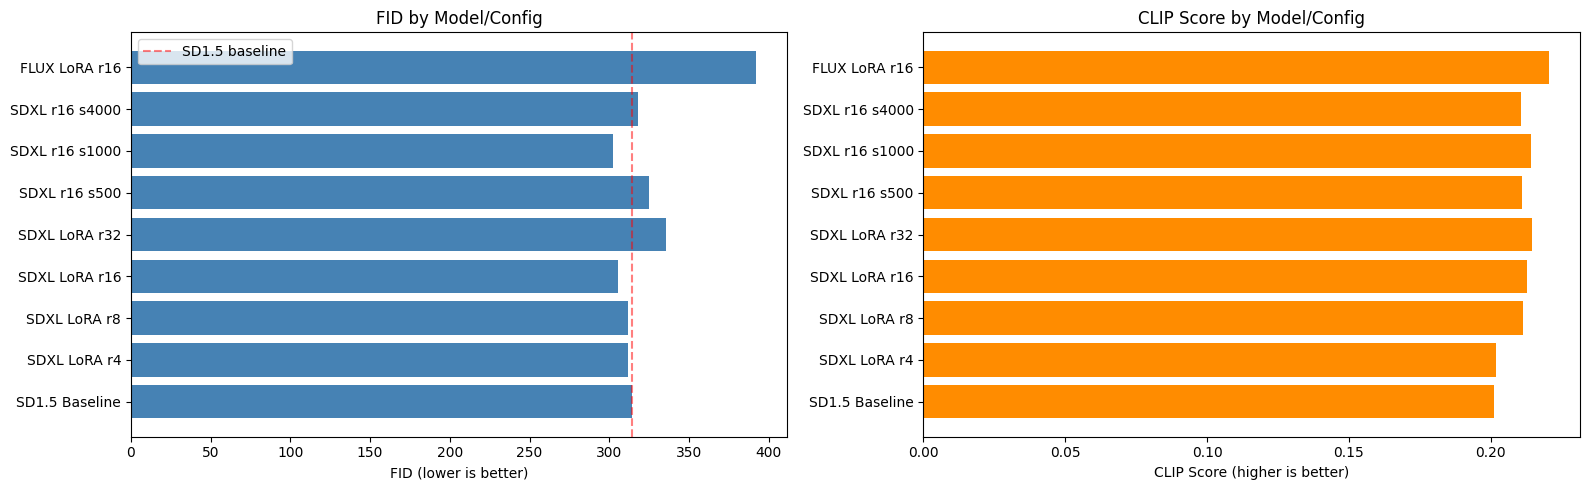


Model                          FID   CLIP Score
-----------------------------------------------
SD1.5 Baseline              314.51       0.2012
SDXL LoRA r4                312.03       0.2018
SDXL LoRA r8                311.46       0.2114
SDXL LoRA r16               305.75       0.2129
SDXL LoRA r32               335.37       0.2147
SDXL r16 s500               324.74       0.2109
SDXL r16 s1000              302.15       0.2143
SDXL r16 s4000              318.07       0.2107
FLUX LoRA r16               392.21       0.2204


In [6]:
import json

import matplotlib.pyplot as plt

with open(f'{DRIVE_ROOT}/results/metrics/all_metrics.json') as f:
    metrics = json.load(f)

if not metrics:
    print("No metrics to plot - run Cell 2 first")
else:
    names = list(metrics.keys())
    fids  = [metrics[n]['fid'] for n in names]
    clips = [metrics[n]['clip_score'] for n in names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.barh(names, fids, color='steelblue')
    ax1.set_xlabel("FID (lower is better)")
    ax1.set_title("FID by Model/Config")
    sd15_fid = metrics.get("SD1.5 Baseline", {}).get("fid")
    if sd15_fid is not None:
        ax1.axvline(sd15_fid, color='red', linestyle='--', alpha=0.5, label='SD1.5 baseline')
        ax1.legend()

    ax2.barh(names, clips, color='darkorange')
    ax2.set_xlabel("CLIP Score (higher is better)")
    ax2.set_title("CLIP Score by Model/Config")

    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/results/metrics/metrics_comparison.png', dpi=150)
    plt.show()

    print(f"\n{'Model':<25} {'FID':>8} {'CLIP Score':>12}")
    print("-" * 47)
    for name in names:
        print(f"{name:<25} {metrics[name]['fid']:>8.2f} {metrics[name]['clip_score']:>12.4f}")
